In [1]:
import pandas as pd

from pandas import json_normalize
from SPARQLWrapper import SPARQLWrapper, JSON
import matplotlib.pyplot as plt
import plotly.express as px

import os

In [3]:
#https://github.com/SuLab/sparql_to_pandas/blob/master/SPARQL_pandas.ipynb
def query_wikidata(sparql_query, sparql_service_url):
    """
    Query the endpoint with the given query string and return the results as a pandas Dataframe.
    """
    # create the connection to the endpoint
    # Wikidata enforces now a strict User-Agent policy, we need to specify the agent
    # See here https://www.wikidata.org/wiki/Wikidata:Project_chat/Archive/2019/07#problems_with_query_API
    # https://meta.wikimedia.org/wiki/User-Agent_policy
    sparql = SPARQLWrapper(sparql_service_url, agent="Sparql Wrapper on Jupyter example")  
    
    sparql.setQuery(sparql_query)
    sparql.setReturnFormat(JSON)

    # ask for the result
    result = sparql.query().convert()
    return json_normalize(result["results"]["bindings"])

## Simple Table

In [4]:
def simple_table(dataframe):
    table = dataframe.filter(regex='.value')
    table = table.rename(columns = lambda col: col.replace(".value", ""))
    
    return table

In [8]:
#clickable
def make_clickable(val):
    # target _blank to open new window
    return '<a target="_blank" href="{}">{}</a>'.format(val,val)

table = table.style.format({'item': make_clickable})

## Graph

In [15]:
sparql_query = """
    #defaultView:Graph
    SELECT ?item ?itemLabel ?pic ?linkTo ?linkToLabel
    WHERE
    {
      wd:Q42196 wdt:P171* ?item
      OPTIONAL { ?item wdt:P171 ?linkTo }
      OPTIONAL { ?item wdt:P18 ?pic }
      SERVICE wikibase:label {bd:serviceParam wikibase:language "en" }
    }
    """
#to query another endpoint, change the URL for the service and the query
sparql_service_url = "https://query.wikidata.org/sparql"
result_table = query_wikidata(sparql_query, sparql_service_url)

In [4]:
result_table.head()

,item.type,item.value,linkTo.type,linkTo.value,pic.type,pic.value,itemLabel.xml:lang,itemLabel.type,itemLabel.value
0,uri,http://www.wikidata.org/entity/Q160,uri,http://www.wikidata.org/entity/Q25833,uri,http://commons.wikimedia.org/wiki/Special:File...,en,literal,Cetacea
1,uri,http://www.wikidata.org/entity/Q160,uri,http://www.wikidata.org/entity/Q7993757,uri,http://commons.wikimedia.org/wiki/Special:File...,en,literal,Cetacea
2,uri,http://www.wikidata.org/entity/Q160,uri,http://www.wikidata.org/entity/Q25833,uri,http://commons.wikimedia.org/wiki/Special:File...,en,literal,Cetacea
3,uri,http://www.wikidata.org/entity/Q160,uri,http://www.wikidata.org/entity/Q7993757,uri,http://commons.wikimedia.org/wiki/Special:File...,en,literal,Cetacea
4,uri,http://www.wikidata.org/entity/Q729,uri,http://www.wikidata.org/entity/Q19088,uri,http://commons.wikimedia.org/wiki/Special:File...,en,literal,animal


In [67]:
table = simple_table(result_table)
table.head()

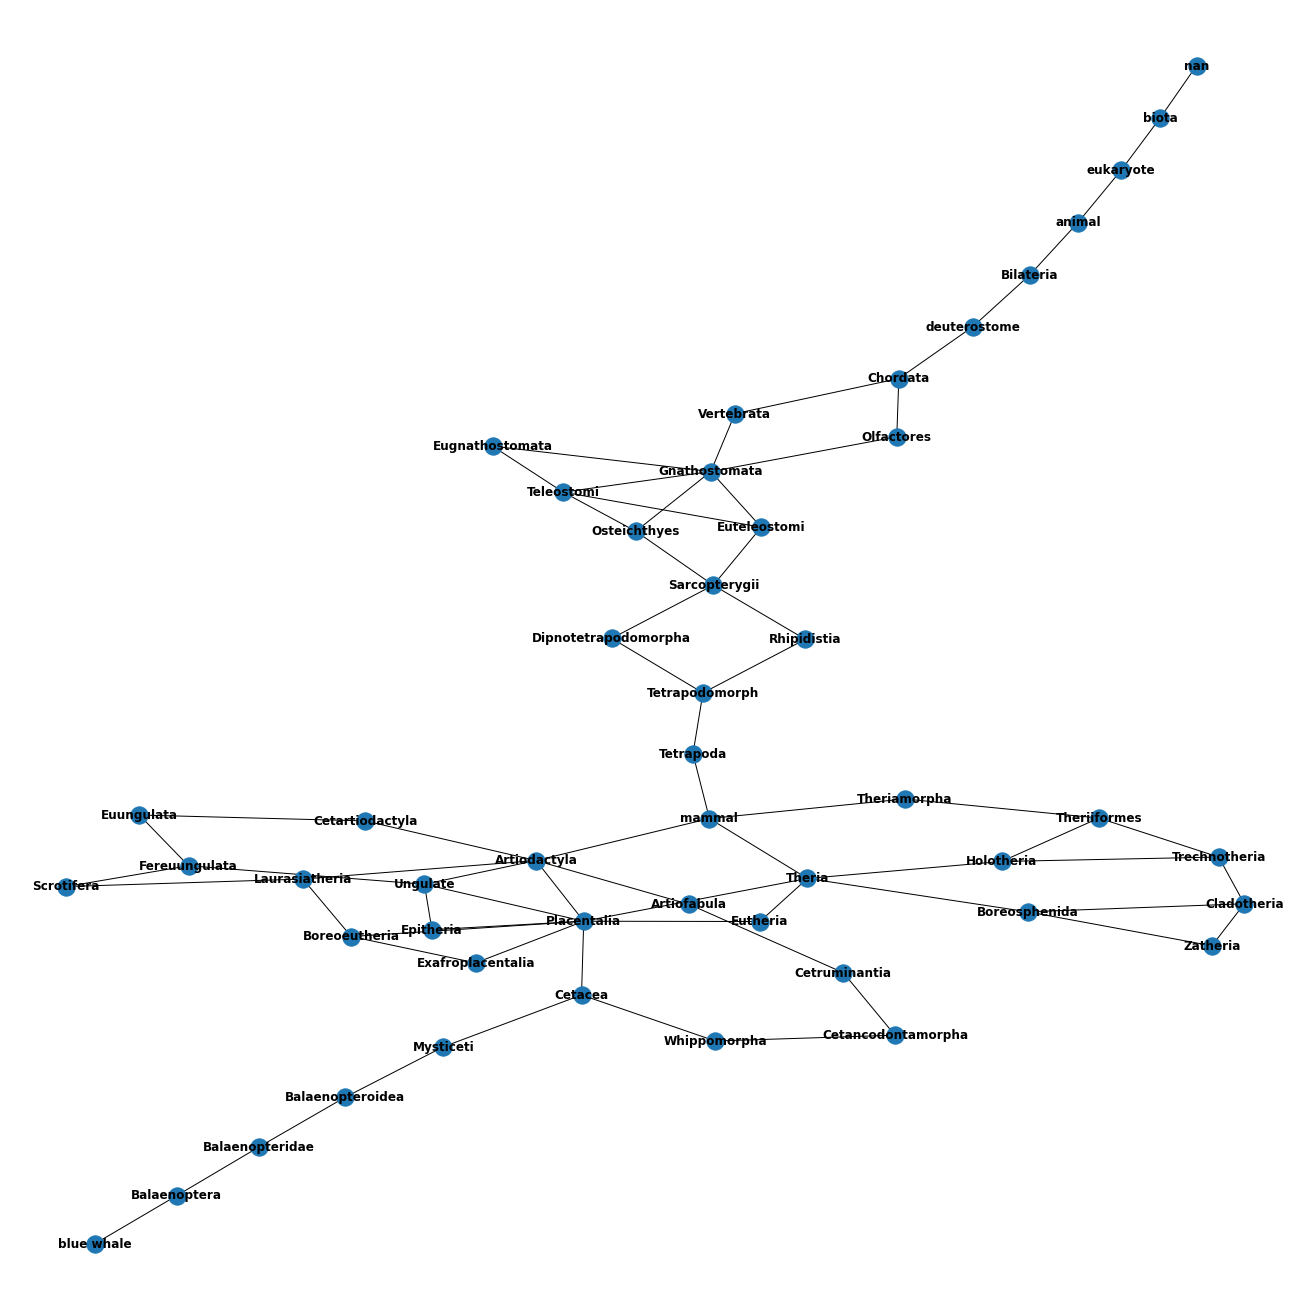

In [47]:
import networkx as nx

G = nx.from_pandas_edgelist(table, source='itemLabel', target='linkToLabel') #, edge_attr=''
plt.figure(figsize=(18,18))
nx.draw_kamada_kawai(G, with_labels=True, font_weight='bold') 
#draw_kamada_kawai, draw_random, draw_networkx, draw_circular, draw_spring, draw_spectral, draw_shell

## Dimension

In [57]:
sparql_query = """
    #Gender and ethnic distribution in the National Hero of Indonesia
    #defaultView:Dimensions
    SELECT ?name ?nameLabel ?ethnicLabel ?genderLabel WHERE {
      ?name wdt:P166 wd:Q1369309;
            wdt:P21 ?gender;
            wdt:P172 ?ethnic .
      SERVICE wikibase:label { bd:serviceParam wikibase:language "[AUTO_LANGUAGE],en". }
    }
    """
#to query another endpoint, change the URL for the service and the query
sparql_service_url = "https://query.wikidata.org/sparql"
result_table = query_wikidata(sparql_query, sparql_service_url)

In [68]:
table = simple_table(result_table)
table.head()

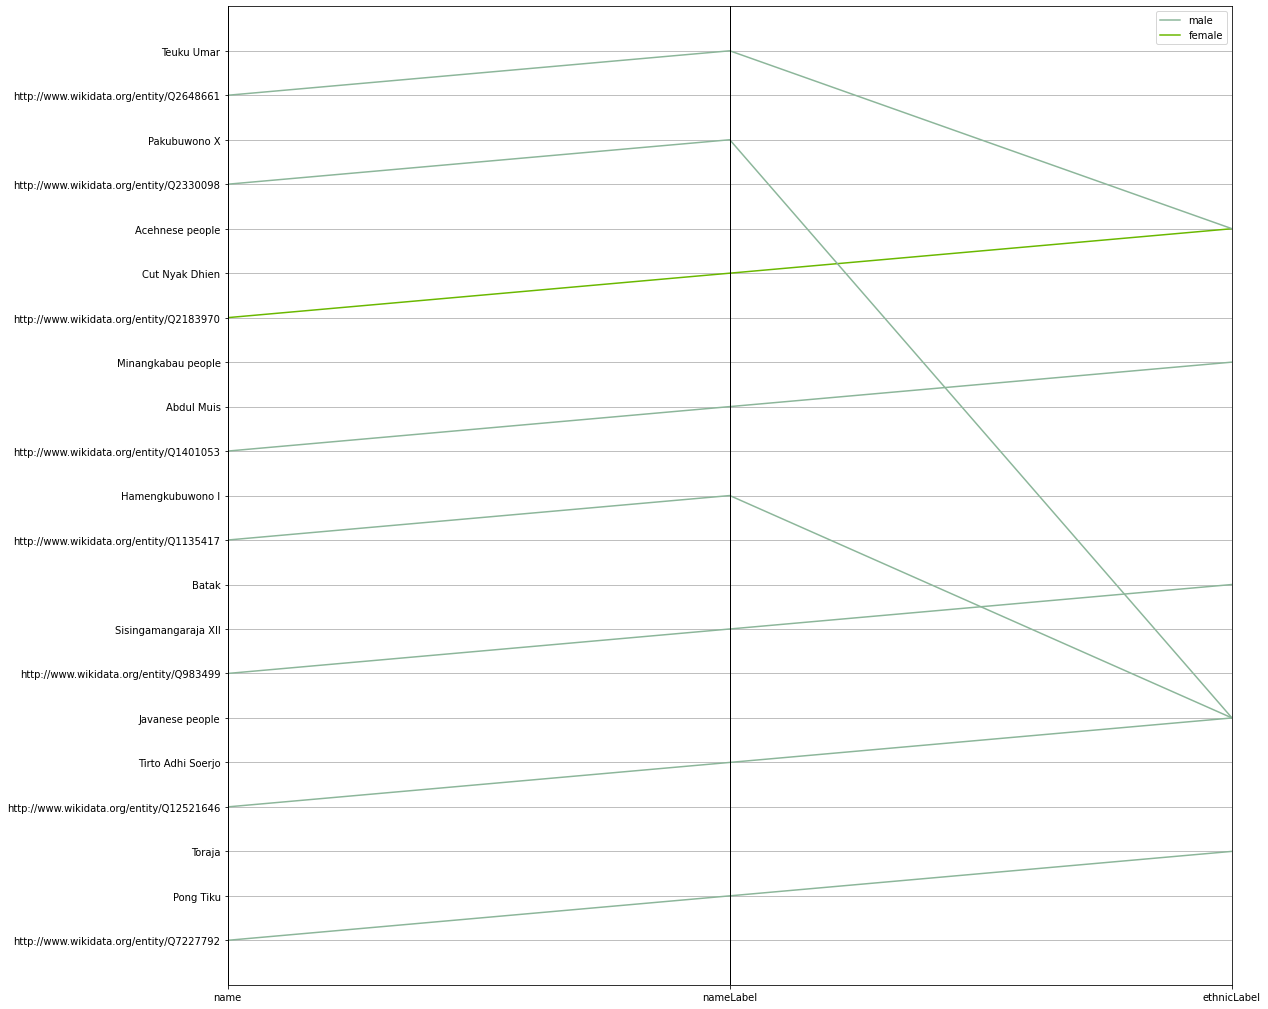

In [59]:
plt.figure(figsize=(18,18))
pd.plotting.parallel_coordinates(table, "genderLabel");

## TreeMaps

In [83]:
sparql_query = """
    #defaultView:TreeMap
    SELECT ?eyes ?hairColorLabel (COUNT(?person) as ?count)
    WHERE
    {
            ?person wdt:P1340 ?eyeColor.
        ?person wdt:P1884 ?hairColor.
        ?person wdt:P2048 ?height.
        ?eyeColor rdfs:label ?_eyeColorLabel.
        FILTER((LANG(?_eyeColorLabel)) = "en")
        BIND(CONCAT(?_eyeColorLabel, " eyes") AS ?eyes)

            SERVICE wikibase:label { bd:serviceParam wikibase:language "en". }

    }
    GROUP BY ?eyes ?hairColorLabel
    ORDER BY DESC(?count)
    """
#to query another endpoint, change the URL for the service and the query
sparql_service_url = "https://query.wikidata.org/sparql"
result_table = query_wikidata(sparql_query, sparql_service_url)

In [84]:
table = simple_table(result_table)

In [85]:
fig = px.treemap(table, path=['eyes', 'hairColorLabel'], values='count')
fig.show()